# Q4 Tail Risk & Stress Testing Framework
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom portfolio stress tester framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework applies Monte Carlo simulation, historical crisis replay, and tail risk decomposition to a mixed-asset universe.

Objectives:
- Provide an evidence-based decision-making tool: Test your trading hypotheses with historical data.
- Allow strategy refinement: Identify strengths and weaknesses in your approach.
- Risk management: Understand potential returns and their respective volatility.
- Performance comparison: Benchmark the portfolio against two optimization methods.
- Flexibility: Custom-built framework allows for complete control over testing parameters.

This framework provides a solid foundation for quantitative trading strategy development and evaluation.

### This framework builds on Q3, it takes the assets and optimized weights for minimum variance and performs a stress test.

## 2. Data Pipeline

The structure of the data flow is as follows:

1. Data loading and correlation matrices
    - Fetches and cleans historical price data for different stocks, crypto and ETFs, and bonds.
    - Annualizes returns, volatility, and covariance matrix
    - Plots correlation and covariance heatmaps 

2. MC simulation: normal vs t, loss distributions, VaR/ES comparison
    - A

3. Historical replay: COVID and 2022, loss distributions, VaR/ES
    - A

4. Cross-scenario comparison table
    - A

5. Tail risk contributions: equal vs min-var weights, both crises
    - A

6. Visualisation
    - A

This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

import sys
sys.path.append('../utils')   # path relative to the notebook
from Q4t_functions import *
from common import fetch_portfolio_data

## 3. Signal Generation

The historical data is downloaded by the function `fetch_portfolio_data()`.
The market cap for each asset is obtained by the function `market_cap()`.
The returns, volatility, and covariance are calculated by the function `returns_volatility()`.

In [2]:
# Load data
starting_capital = 120_500
period = 100
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

tickersS = ['AAPL', 'NVDA', 'CVX', 'TSM']
tickersC = ['BTC-USD', 'ETH-USD']
tickersE = ['SPY', 'VEA', 'GLD', 'TLT']

dataS, _ = fetch_portfolio_data(tickersS, start, end)
dataC, _ = fetch_portfolio_data(tickersC, start, end)
dataE, _ = fetch_portfolio_data(tickersE, start, end)

In [3]:
# checking data
print(dataS.shape)
print(dataS.isna().sum())
print(dataS.index.min(), dataS.index.max())
print()
print(dataC.shape)
print(dataC.isna().sum())
print(dataC.index.min(), dataC.index.max())
print()
print(dataE.shape)
print(dataE.isna().sum())
print(dataE.index.min(), dataE.index.max())
print()

# Combine with outer join, forward fill, then align to common start
dataALL = pd.concat([dataS, dataC, dataE], axis=1)
dataALL = dataALL.ffill()
#dataALL = dataALL.dropna()  # drops pre-crypto period
dataALL = dataALL.sort_index()
print(dataALL.shape)
print(dataALL.index.min())

(6854, 4)
Ticker
AAPL    0
CVX     0
NVDA    0
TSM     0
dtype: int64
1999-01-22 00:00:00 2026-04-22 00:00:00

(3087, 2)
Ticker
BTC-USD    0
ETH-USD    0
dtype: int64
2017-11-09 00:00:00 2026-04-22 00:00:00

(4715, 4)
Ticker
GLD    0
SPY    0
TLT    0
VEA    0
dtype: int64
2007-07-26 00:00:00 2026-04-22 00:00:00

(7819, 10)
1999-01-22 00:00:00


/var/folders/89/hrgs9sm57xz4lcmzgjzdswph0000gn/T/ipykernel_58239/840653899.py:16: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  dataALL = pd.concat([dataS, dataC, dataE], axis=1)


## 4. Correlation Analysis

The correlation matrix reveals the diversification structure:
- **SPY/VEA:** 0.86 — international equities are nearly a clone of US equities
- **BTC/ETH:** 0.78 — crypto moves as a single asset block
- **TLT vs equities:** −0.09 to −0.19 — the only genuinely negative correlator
- **GLD:** 0.06–0.13 with equities — near-zero correlation, true diversifier

These baseline correlations will be tested under crisis conditions.

,Annualized_Return,Annualized_Volatility
Ticker,,
AAPL,0.205166,0.252366
CVX,0.105962,0.256424
NVDA,0.475146,0.419554
TSM,0.274527,0.299053
BTC-USD,0.417939,0.552786
ETH-USD,0.520035,0.711045
GLD,0.119807,0.136731
SPY,0.112081,0.158864
TLT,-0.002902,0.128588


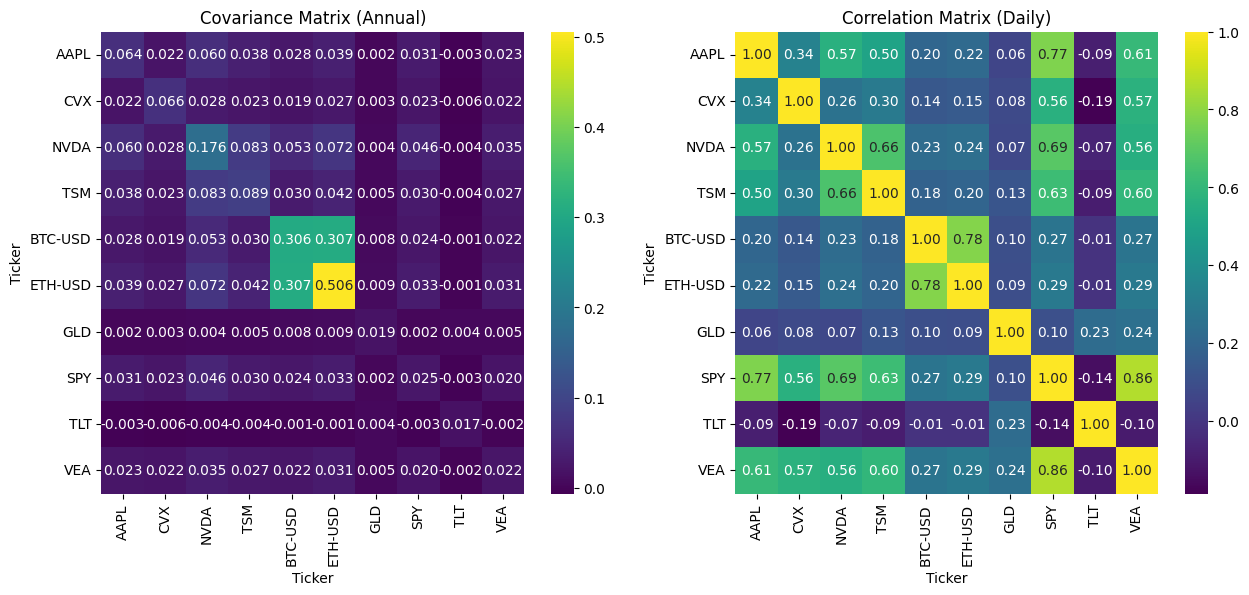

In [4]:
mu_annual, sigma_annual, cov_annual, corr_matrix = returns_volatility(dataALL)

In [5]:
# Tickers
tickers = dataALL.columns.tolist()

weights = np.ones(len(tickers)) / len(tickers)
weights = [0.00000000e+00, 3.98678456e-02, 1.28847071e-17, 5.54283383e-18, 0.00000000e+00, 3.43985168e-18, 2.32530702e-01, 2.28667315e-01, 4.41365419e-01, 5.75687178e-02] # set individual weights per asset [0.1, 0.2, 0.7]


values = weights * starting_capital
initial_portfolio_value = np.sum(values)

n_sims = 10_000
CI = 0.95  # 95% confidence

## 5. MC simulated returns

- Simulate 10,000 correlated futures
- Collapse to portfolio level
- Compound daily returns into a growth path
- Take the endpoint of each path
- Analyse the distribution of outcomes.


Returns:
 Mean: 6.17%
 Std: 8.99%


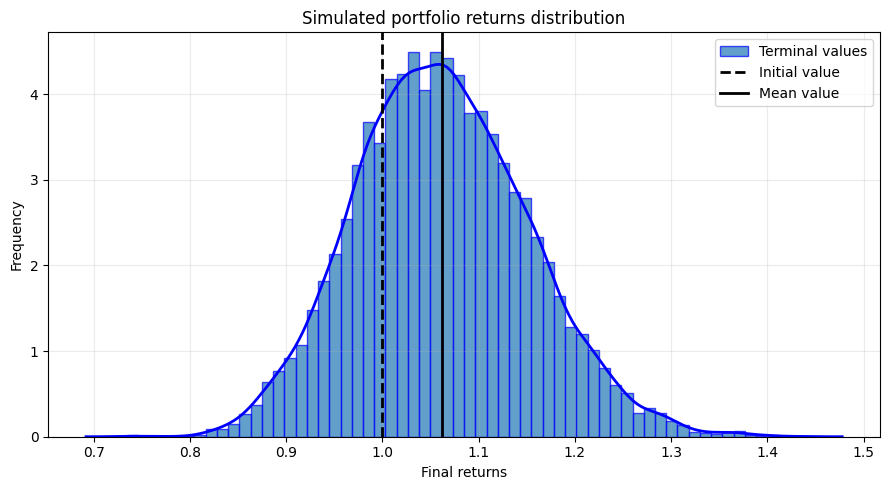

In [6]:
forw_returns = forward_returns(mu_annual, cov_annual, 't', n_sims, 252, df_t=6) # shape (252, n_sims, N)
portfolio_returns =  forw_returns @ weights                                  # shape (252, n_sims)
cumulative_returns = np.cumprod(1 + portfolio_returns, axis=0)               # shape (252, n_sims)
terminal_values = cumulative_returns[-1]                                     # shape (n_sims)

print("\nReturns:")
print(f" Mean: {terminal_values.mean()-1:.2%}")
print(f" Std: {terminal_values.std():.2%}")

plt.figure(figsize=(9,5))
plt.hist(terminal_values, bins=60, density=True, edgecolor='b', alpha=0.7, label='Terminal values')
sns.kdeplot(terminal_values, color='b', linewidth=2)
plt.axvline(1, color='k', linestyle='--', linewidth= 2, label='Initial value')
plt.axvline(terminal_values.mean(), color='k', linestyle='-', linewidth= 2, label='Mean value')

plt.xlabel("Final returns")
plt.ylabel("Frequency")
plt.title("Simulated portfolio returns distribution")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

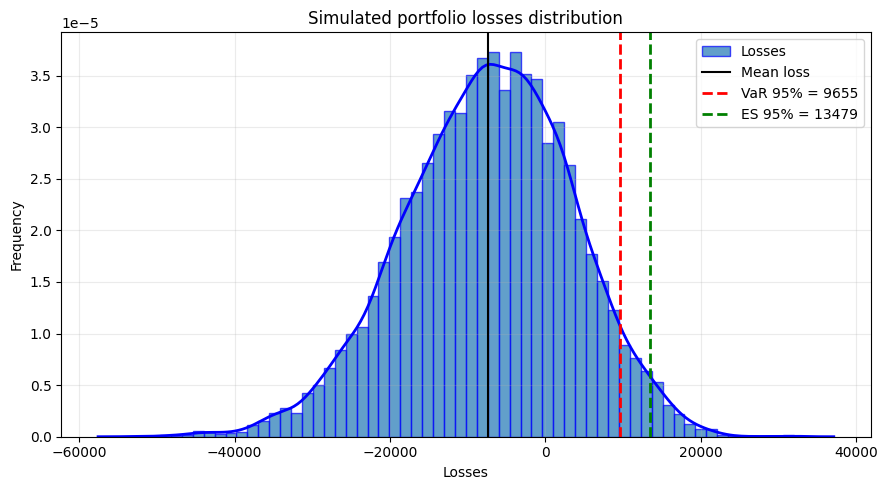

Loss distribution summary:
VaR 95: 9,655 (8.01%)
ES  95: 13,479 (11.19%)
Min loss: -52,425 (-43.51%)
Max loss: 31,972 (26.53%)
Mean loss: -7,438 (-6.17%)


In [19]:
losses_pct, losses_pnl = loss_calculator(terminal_values, 1, starting_capital)

VaR_95, ES_95, VaR_95_rel, ES_95_rel = losses_var_es(losses_pnl, losses_pct, CI=95)

plt.figure(figsize=(9,5))
plt.hist(losses_pnl,bins=60, density=True, edgecolor="b", alpha=0.7, label='Losses')
sns.kdeplot(losses_pnl, color='b', linewidth=2)
plt.axvline(losses_pnl.mean(), color='k', linestyle='-', linewidth= 1.5, label='Mean loss')
plt.axvline(VaR_95, color='r', linestyle="--", linewidth=2, label=f"VaR 95% = {VaR_95:.0f}")
plt.axvline(ES_95, color='g', linestyle="--", linewidth=2, label=f"ES 95% = {ES_95:.0f}")

plt.xlabel("Losses")
plt.ylabel("Frequency")
plt.title("Simulated portfolio losses distribution")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



print("Loss distribution summary:")
print(f"VaR 95: {VaR_95:,.0f} ({VaR_95_rel:.2%})")
print(f"ES  95: {ES_95:,.0f} ({ES_95_rel:.2%})")
print(f"Min loss: {losses_pnl.min():,.0f} ({losses_pct.min():.2%})")
print(f"Max loss: {losses_pnl.max():,.0f} ({losses_pct.max():.2%})")
print(f"Mean loss: {losses_pnl.mean():,.0f} ({losses_pct.mean():.2%})")

## 6. Historical Crisis Replay

Extract actual daily returns during defined crisis windows (COVID-19, 2022 Rate Shock) and compute cumulative portfolio losses day by day. Each trading day represents a scenario: "what if I had to liquidate today?"


### Crisis Windows Tested
| Event | Window | Character |
|-------|--------|-----------|
| COVID-19 Recession | 2020-02-01 → 2020-04-30 | Sharp crash, fast V-shaped recovery |
| 2022 Rate Shock | 2022-01-03 → 2022-12-31 | Sustained grind, no recovery within window |

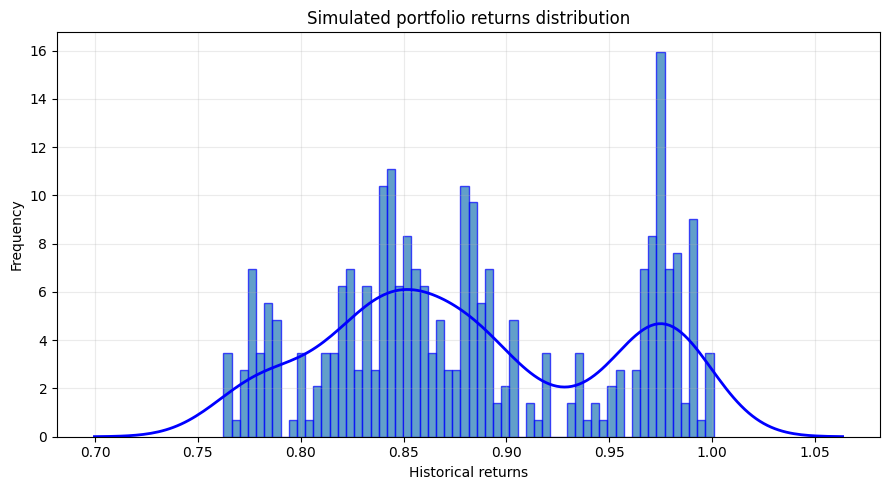

In [8]:
#historical events: Emerging‑Market Crisis, Dot‑com Bubble Burst, Great Recession, European Debt Crisis, COVID‑19 Recession, 2022 Rate Shock.
hist_returns = historical_returns(dataALL, "2022 Rate Shock")          # shape (days, N)
hist_portfolio = hist_returns @ weights                                     # shape (days)
hist_cumulative = np.cumprod(1 + hist_portfolio.dropna())                   # shape (days)
hist_values = hist_cumulative

plt.figure(figsize=(9,5))
plt.hist(hist_values, bins=60, density=True, edgecolor="b", alpha=0.7)
sns.kdeplot(hist_values, color='b', linewidth=2)

plt.xlabel("Historical returns")
plt.ylabel("Frequency")
plt.title("Simulated portfolio returns distribution")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### VaR Comparison Across Scenarios ($120,500 starting capital)

| Scenario | VaR 95% | ES 95% | Character |
|---|---|---|---|
| **MC Normal** | 7.8% ($9,447) | 11.0% ($13,230) | Baseline forward-looking |
| **MC Student-t (ν=4)** | 10.7% ($12,865) | 17.7% ($21,331) | Fatter tails, marginal improvement |
| **COVID-19 (equal weights)** | 25.5% ($30,729) | 26.5% ($31,935) | Sharp crash, thin tail beyond VaR |
| **2022 Rate Shock (equal weights)** | 37.4% ($45,096) | 38.4% ($46,227) | Sustained grind, 47% worse than COVID |

**Key finding:** Monte Carlo VaR massively underestimates real crisis severity. The normal-distribution MC predicted 7.8% VaR; COVID delivered 25.5%, 2022 delivered 37.4%. Even fat-tailed Student-t barely moved the needle (10.7%). Historical simulation is the only honest tail risk measure.


### Portfolio Weight Comparison: Equal vs Min-Variance

Tested two weight sets across both crises:

**Equal weights:** 10% per asset  
**Min-variance weights (from Q4 optimizer):** TLT 42%, SPY 25%, GLD 27%, VEA 4%, CVX 3%, all others 0%

#### COVID-19 Results

| Weights | VaR 95% | ES 95% | Top loss driver |
|---|---|---|---|
| Equal | 25.5% | 26.5% | ETH (26%) + BTC (20%) + CVX (15%) |
| Min-Var | **8.9%** | 10.6% | SPY (63%) only |

Min-variance cut COVID losses by **65%**. Heavy TLT/GLD allocation worked exactly as designed — these assets contributed 0.06% and 0.24% respectively to tail losses.

#### 2022 Rate Shock Results

| Weights | VaR 95% | ES 95% | Top loss driver |
|---|---|---|---|
| Equal | 37.4% | 38.4% | ETH (21%) + BTC (17%) + NVDA (17%) |
| Min-Var | **22.2%** | 22.8% | **TLT (60%)** |

Min-variance only cut rate shock losses by **41%** (vs 65% in COVID). The asset that saved the portfolio in 2020 became the killer in 2022. TLT went from 0.06% contribution in COVID to 60% in the rate shock — a 1000x flip in risk profile.

---

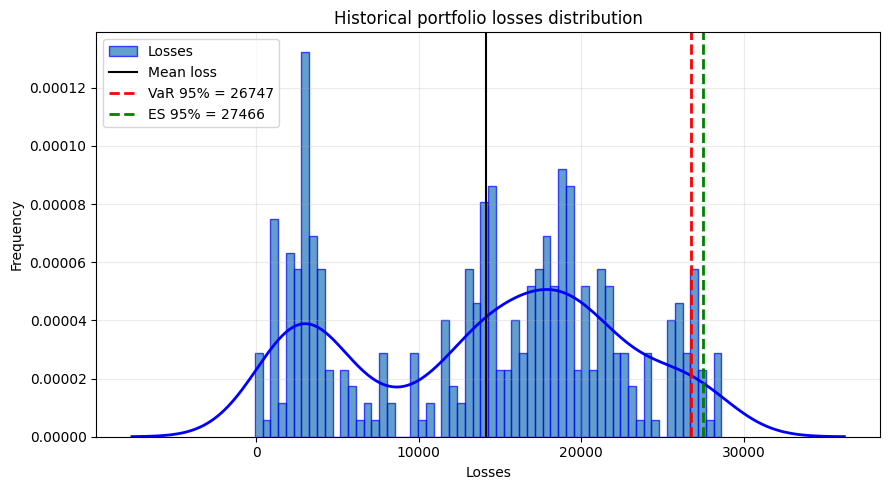

Loss distribution summary:
VaR 95: 26,747 (22.20%)
ES  95: 27,466 (22.79%)
Min loss: -87 (-0.07%)
Max loss: 28,623 (23.75%)
Mean loss: 14,126 (11.72%)


In [18]:
losses_pct, losses_pnl = loss_calculator(hist_values, 1, starting_capital)
VaR_95, ES_95, VaR_95_rel, ES_95_rel = losses_var_es(losses_pnl, losses_pct, CI=95)

plt.figure(figsize=(9,5))
plt.hist(losses_pnl, bins=60, density=True, edgecolor="b", alpha=0.7, label='Losses')
sns.kdeplot(losses_pnl, color='b', linewidth=2)
plt.axvline(losses_pnl.mean(), color='k', linestyle='-', linewidth= 1.5, label='Mean loss')

plt.axvline(VaR_95, color='r', linestyle="--", linewidth=2, label=f"VaR 95% = {VaR_95:.0f}")
plt.axvline(ES_95, color='g', linestyle="--", linewidth=2, label=f"ES 95% = {ES_95:.0f}")

plt.xlabel("Losses")
plt.ylabel("Frequency")
plt.title("Historical portfolio losses distribution")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



print("Loss distribution summary:")
print(f"VaR 95: {VaR_95:,.0f} ({VaR_95_rel:.2%})")
print(f"ES  95: {ES_95:,.0f} ({ES_95_rel:.2%})")
print(f"Min loss: {losses_pnl.min():,.0f} ({losses_pct.min():.2%})")
print(f"Max loss: {losses_pnl.max():,.0f} ({losses_pct.max():.2%})")
print(f"Mean loss: {losses_pnl.mean():,.0f} ({losses_pct.mean():.2%})")

## 7. Tail Risk Contribution

For the worst X% of days (by portfolio cumulative return), decompose losses into per-asset contributions:

$$C_i = w_i \times (r_i - 1)$$

Positive = asset hurt the portfolio. Negative = asset helped. This answers: "what killed me?"

### Tail Risk Contributions: The "What Kills You" View

**COVID-19 (min-var weights, worst 75% of days):**

| Asset | Contribution |
|-------|--------------|
| SPY | 63% |
| CVX | 17% |
| VEA | 11% |
| **TLT** | **0.06%** ← safe haven |
| **GLD** | **0.24%** ← safe haven |

**2022 Rate Shock (min-var weights, worst 75% of days):**

| Asset | Contribution |
|-------|--------------|
| **TLT** | **60%** ← single largest killer |
| SPY | 23% |
| GLD | 12% |
| VEA | 6% |
| CVX | -1.4% ← actually helped (energy rally) |

The same optimizer, the same "safe" allocation, opposite outcomes. **There is no unconditional safe haven.**

In [10]:
# Tail risk contributions (worst X% outcomes by portfolio value)
X = .95

tail_contrib = tail_risk_contribution(hist_returns, weights, tickers, X)

print(f"\nTail loss contributions (worst {X:2.0%}) [%]:")
display(tail_contrib.round(2))


Tail loss contributions (worst 95%) [%]:


TLT        8.72
SPY        3.60
VEA        0.92
GLD        0.21
NVDA       0.00
ETH-USD    0.00
TSM        0.00
AAPL       0.00
BTC-USD    0.00
CVX       -1.33
dtype: float64

## 8. Simulated returns using hitorical metrics

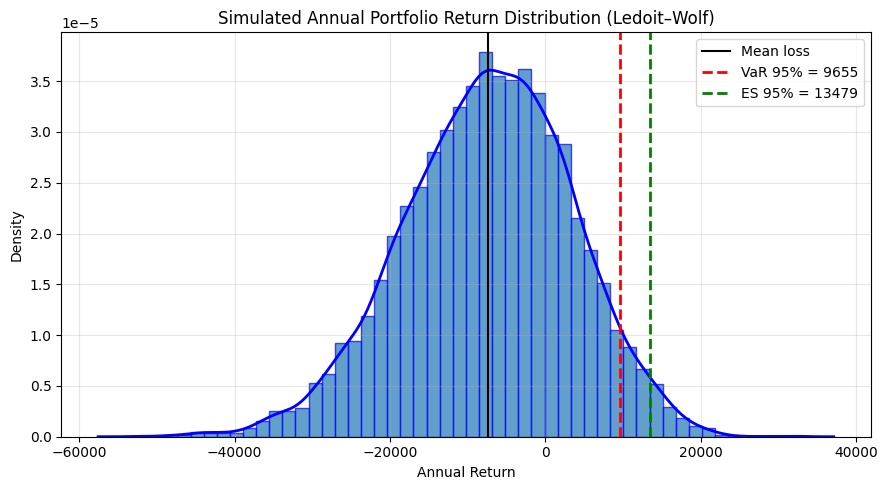

Loss distribution summary:
VaR 95: 9,655 (8.01%)
ES  95: 13,479 (11.19%)
Min loss: -52,425 (-43.51%)
Max loss: 31,972 (26.53%)
Mean loss: -7,438 (-6.17%)


In [22]:
sim_portfolio_ret, _, _ = simulate_annual_returns(hist_returns, weights, n_sims, seed=314)
loss_pct, loss_pnl = loss_calculator(sim_portfolio_ret, 0, initial_portfolio_value)
VaR_95, ES_95, VaR_95_rel, ES_95_rel = losses_var_es(losses_pnl, losses_pct, CI=95)

plt.subplots(figsize=(9, 5))

plt.hist(losses_pnl, bins=50, density=True, alpha=0.7, edgecolor='b')
# KDE
sns.kdeplot(losses_pnl, color='b', linewidth=2)

plt.axvline(losses_pnl.mean(), color='k', linestyle='-', linewidth= 1.5, label='Mean loss')

# VaR lines
plt.axvline(VaR_95, color='r', linestyle="--", linewidth=2, label=f"VaR 95% = {VaR_95:.0f}")
plt.axvline(ES_95, color='g', linestyle="--", linewidth=2, label=f"ES 95% = {ES_95:.0f}")

plt.title("Simulated Annual Portfolio Return Distribution (Ledoit–Wolf)")
plt.xlabel("Annual Return")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Loss distribution summary:")
print(f"VaR 95: {VaR_95:,.0f} ({VaR_95_rel:.2%})")
print(f"ES  95: {ES_95:,.0f} ({ES_95_rel:.2%})")
print(f"Min loss: {losses_pnl.min():,.0f} ({losses_pct.min():.2%})")
print(f"Max loss: {losses_pnl.max():,.0f} ({losses_pct.max():.2%})")
print(f"Mean loss: {losses_pnl.mean():,.0f} ({losses_pct.mean():.2%})")

## 9. Rolling volatility

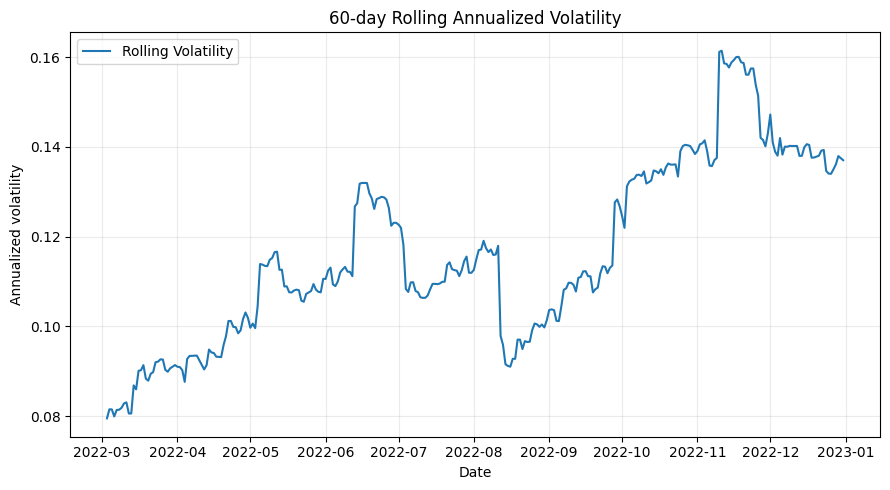

In [15]:
window = 60

# log_returns: DataFrame of daily log returns (columns = assets)
roll_vol = hist_portfolio.rolling(window).std() * np.sqrt(252)

plt.figure(figsize=(9,5))

plt.plot(roll_vol, linestyle='-', linewidth= 1.5, label='Rolling Volatility')

plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.title("60-day Rolling Annualized Volatility")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Conclusions

For this particular scenario, in which we look back at ~20-year data from hand-picked stocks, cryptocurrencies, and ETFs/Bonds to achieve asset class diversification.

For this portfolio, the following assets have been selected:
   1. Stocks: Apple, Nvidia, Chevron, Taiwan Semiconductor
   2. Cryptocurrencies: Bitcoin, Ethereum
   3. ETFs/Bonds: S&P500 index, Gold, Treasury bond, Developed Markets

These 10 assets have equally distributed weights (10% each) as a starting point and have been optimised optimized by markovitz for minimum variance in Q4. We can draw the following conclusions:

- **Monte Carlo simulation systematically underprices tail risk.** Normal-distribution MC predicted 7.8% VaR. Reality delivered 25–37%. Even Student-t fat tails barely helped. The problem is structural: MC uses the normal-regime covariance matrix, which doesn't know that correlations converge in crises. Diversification disappears exactly when you need it.

- **Crisis character matters more than crisis severity.** COVID was a sharp, fear-driven crash where TLT and GLD worked as designed. The 2022 rate shock was an inflation-driven grind where bonds and equities fell simultaneously. VaR numbers alone miss this — you need per-asset loss decomposition to understand *why* the portfolio failed.

- **Min-variance optimization is regime-specific.** The optimizer correctly allocated to TLT and GLD because they had negative correlations with equities *in the historical data*. It could not foresee a regime shift where those correlations break down. The lesson: backward-looking covariance is a poor guide to forward tail risk.

- **Crypto was the predicted tail risk, TLT was the surprise.** The optimizer zeroed out crypto in the min-variance portfolio — recognizing it as high-vol and correlated with equities. That call was vindicated in both crises. The catastrophic miss was TLT, which looked safe historically but collapsed when the Fed hiked rates aggressively.

- **CVX provided genuine diversification in 2022.** Energy stocks rallied post-Ukraine invasion while everything else fell. CVX had a *negative* contribution to tail losses in 2022 (−1.4%), meaning it offset losses rather than causing them. This is what real diversification looks like — an asset that zigs when others zag.

## 9. Limitations & Next Steps

The three most important limitations of this model are the following:  
   1. a
   2. b
   3. c

Some interesting next steps to go deeper on this project would be:
- a
- b
- c

Just to name a few.

### 1. Calendar Misalignment (crypto 24/7 vs equities 5-day)

Bitcoin and Ethereum trade weekends and holidays; stocks don't. Forward-filling equity prices through non-trading days preserves all data but slightly understates equity volatility relative to crypto. A more rigorous approach would align all assets to weekly returns before computing covariance, at the cost of reduced sample size.

### 2. Missing Asset Problem for Pre-2017 Crises

BTC begins 2017, ETH begins late 2017. The Great Recession (2007–2009), dot-com crash (2000–2002), and earlier crises cannot be replayed with the full universe. Proxying crypto with high-vol tech stocks introduces modelling assumptions that belong in a caveat, not silently assumed.

### 3. Static Weights with No Rebalancing

All scenarios assume buy-and-hold with fixed percentage weights. In reality, as NVDA rallies 400%, it becomes a much larger fraction of the portfolio, concentrating risk. Rebalancing back to target weights incurs transaction costs and tax drag — both ignored here.

### 4. Single Historical Path per Crisis

Each crisis happened once. COVID VaR is computed from ~60 trading days in Feb–Apr 2020. That's not a large sample for a 95th percentile estimate. Monte Carlo simulations have 10,000 paths; historical replay has one. The statistical uncertainty around historical VaR is larger than the numbers suggest.

### 5. Normal-Regime Covariance for MC

The Monte Carlo engine uses the full 8-year historical covariance matrix, which blends calm and crisis periods. A more sophisticated approach would estimate separate calm-regime and stressed-regime covariance matrices, then test how much correlation converges during actual tail events.



- **Stress-adjusted covariance matrix:** Estimate crisis-regime correlations separately (e.g., rolling correlation during VIX > 30 periods) and compare MC VaR using stressed vs normal covariance
- **Expand crisis library:** Add 2008 GFC using equity-only subset to test bond behavior during the last major recession
- **Dynamic rebalancing simulation:** Test how frequently rebalancing back to min-var weights affects realized tail losses (transaction costs vs risk reduction tradeoff)
- **Regime detection framework:** Build a simple regime classifier (VIX thresholds + MA crossovers) to test whether switching between aggressive/defensive allocations improves risk-adjusted returns
- **Copula-based tail dependence:** Model joint extremes using Student-t copulas rather than multivariate normal to capture the empirical fact that assets crash together more often than normal distributions predict

## A. Apendix - Test windows available

Event                     | Date Range                      | Duration         | Severity
------------------------- | ------------------------------- | ---------------- | --------
Great Depression          | 1929‑08‑01 → 1939‑12‑31         | 10 yrs 5 mos     | Severe
Black Monday              | 1987‑10‑14 → 1987‑12‑31         | 2.5 mos          | High
1990–1991 Recession       | 1990‑07‑01 → 1991‑03‑31         | 9 mos            | Medium
Emerging‑Market Crisis    | 1997‑07‑02 → 1998‑12‑31         | 1 yr 6 mos       | High
Dot‑com Bubble Burst      | 2000‑03‑10 → 2002‑10‑04         | 2 yrs 7 mos      | High
Early 2000s Recession     | 2001‑03‑01 → 2001‑11‑30         | 9 mos            | Medium
Great Recession           | 2007‑12‑01 → 2009‑06‑30         | 1 yr 7 mos       | Severe
European Debt Crisis      | 2010‑04‑01 → 2012‑07‑26         | 2 yrs 4 mos      | High
COVID‑19 Recession        | 2020‑02‑01 → 2020‑04‑30         | 3 mos            | High
2022 Rate Shock           | 2022‑01‑03 → 2022‑12‑31         | 12 mos           | Medium